In [6]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [7]:
iris = load_iris()
X = iris.data
y = iris.target

In [8]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


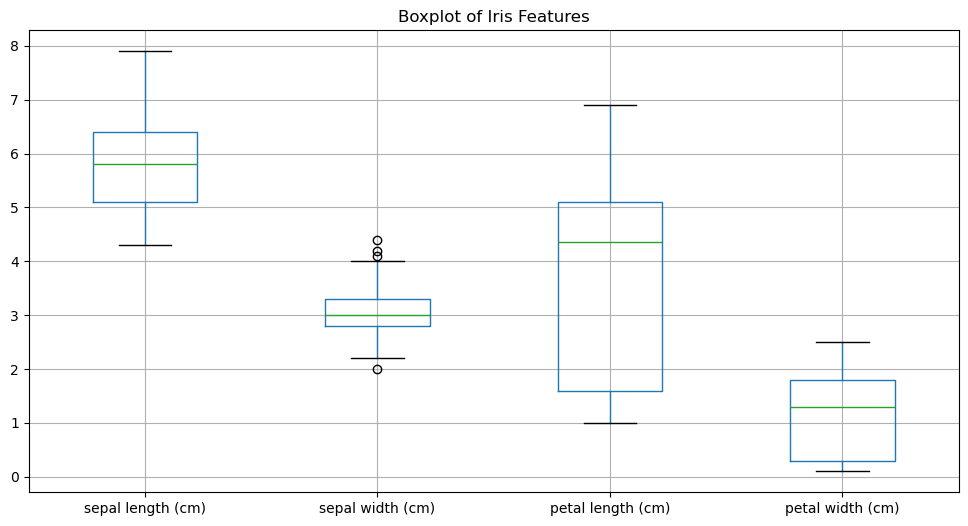

In [9]:
# Plot boxplots for each feature
plt.figure(figsize=(12,6))
df.drop("target", axis=1).boxplot()
plt.title("Boxplot of Iris Features")
plt.show()

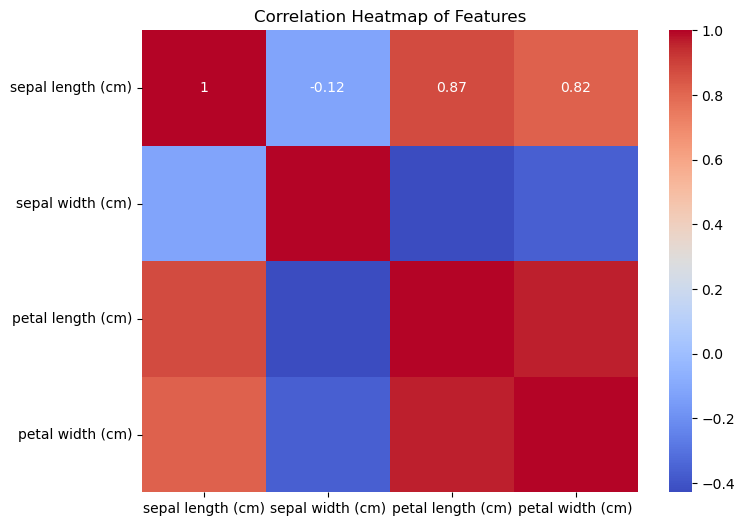

In [10]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.drop("target",axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Features")
plt.show()

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:
Z = linkage(X_scaled, method="ward")

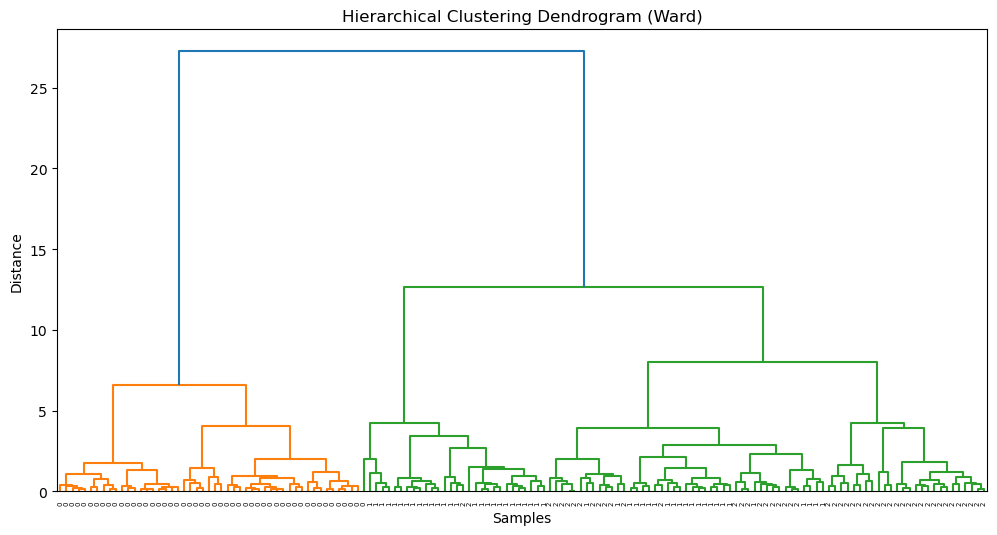

In [13]:
plt.figure(figsize=(12,6))
dendrogram(Z, labels=iris.target, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future

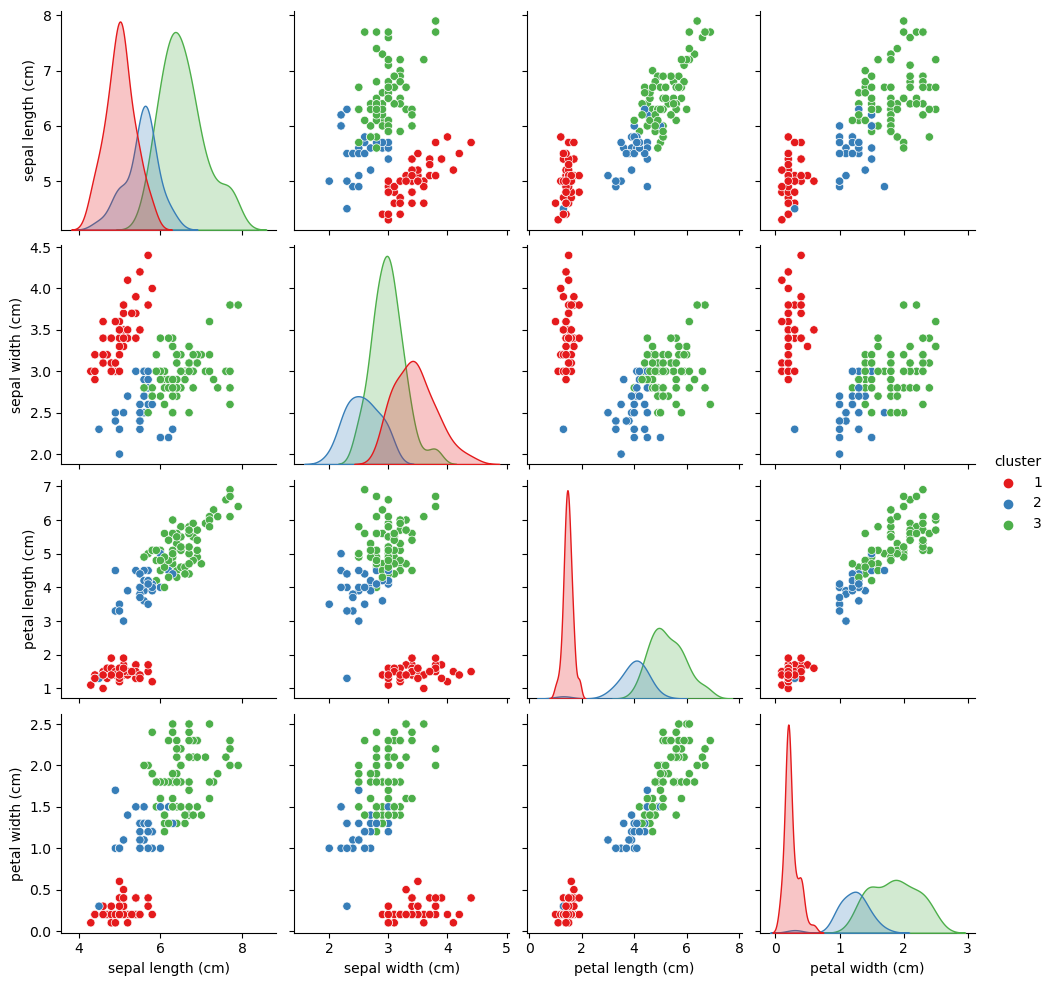

In [14]:
cluster = fcluster(Z, t=3, criterion="maxclust")
df["cluster"]=cluster
# Pairplot for cluster visualization
sns.pairplot(df, vars=iris.feature_names, hue="cluster", palette="Set1")
plt.show()

In [15]:
from sklearn.metrics import confusion_matrix, adjusted_rand_score

# Confusion matrix between real labels and clusters
cm = confusion_matrix(y, df['cluster'])
print("Confusion Matrix:\n", cm)

# Adjusted Rand Index (ARI)
ari = adjusted_rand_score(y, df['cluster'])
print("Adjusted Rand Index:", ari)

Confusion Matrix:
 [[ 0 49  1  0]
 [ 0  0 27 23]
 [ 0  0  2 48]
 [ 0  0  0  0]]
Adjusted Rand Index: 0.6153229932145449


In [16]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
sil_score = silhouette_score(X_scaled, df['cluster'])
print("Silhouette Score:", sil_score)

Silhouette Score: 0.4466890410285909


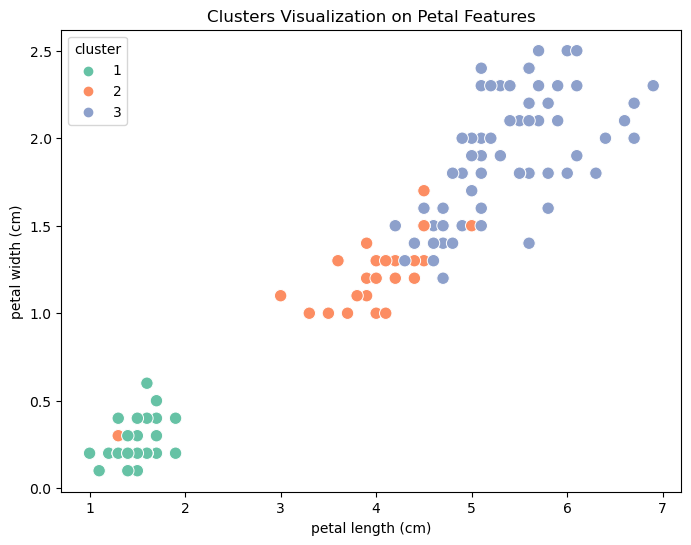

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["petal length (cm)"], y=df["petal width (cm)"], hue=df["cluster"], palette="Set2", s=80)
plt.title("Clusters Visualization on Petal Features")
plt.show()

In [18]:
from sklearn.datasets import make_circles

X_circle, y_circle = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

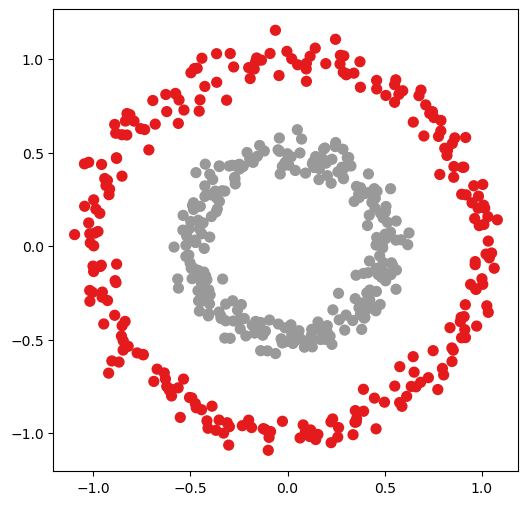

In [21]:
plt.figure(figsize=(6,6))
plt.scatter(x=X_circle[:,0],y=X_circle[:, 1],c=y_circle,cmap="Set1", s=50)
plt.show()

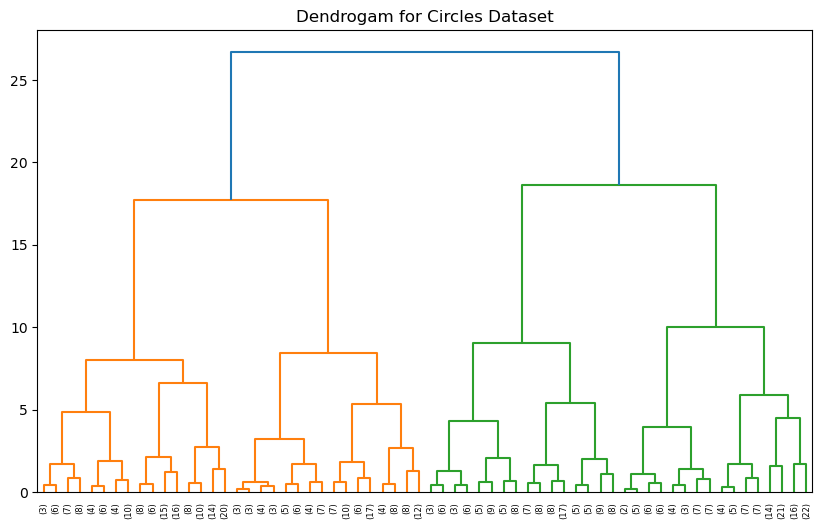

In [28]:
X_circle_scaled = StandardScaler().fit_transform(X_circle)
Z_circle = linkage(X_circle_scaled, method="ward")
plt.figure(figsize=(10,6))
dendrogram(Z_circle, truncate_mode="level", p=5)
plt.title("Dendrogam for Circles Dataset")
plt.show()

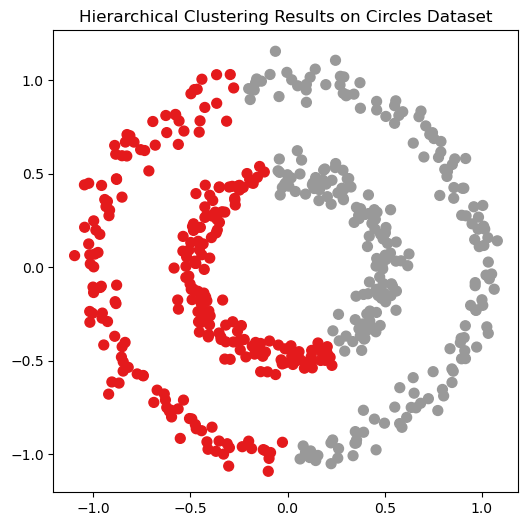

In [34]:
# Form 2 clusters
clusters_circles = fcluster(Z_circle, t=2, criterion="maxclust")

# Plot results
plt.figure(figsize=(6,6))
plt.scatter(X_circle[:,0], X_circle[:,1], c=clusters_circles, cmap="Set1", s=50)
plt.title("Hierarchical Clustering Results on Circles Dataset")
plt.show()

In [36]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

# Calculate ARI and Silhouette Score
ari_circles = adjusted_rand_score(y_circle, clusters_circles)
sil_score_circles = silhouette_score(X_circle_scaled, clusters_circles)

print("ARI (Adjusted Rand Index):", ari_circles)
print("Silhouette Score:", sil_score_circles)

ARI (Adjusted Rand Index): 0.0057516458471780435
Silhouette Score: 0.3451247621048583


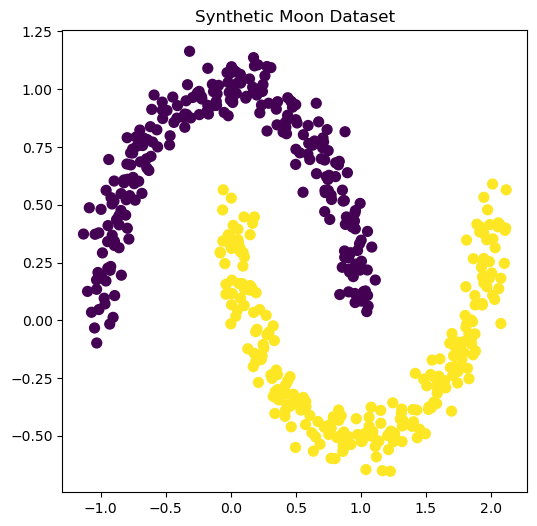

In [38]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=500, noise=0.07, random_state=42)
plt.figure(figsize=(6,6))
plt.scatter(X_moons[:, 0], X_moons[:,1], c=y_moons,cmap="viridis", s=50)
plt.title("Synthetic Moon Dataset")
plt.show()

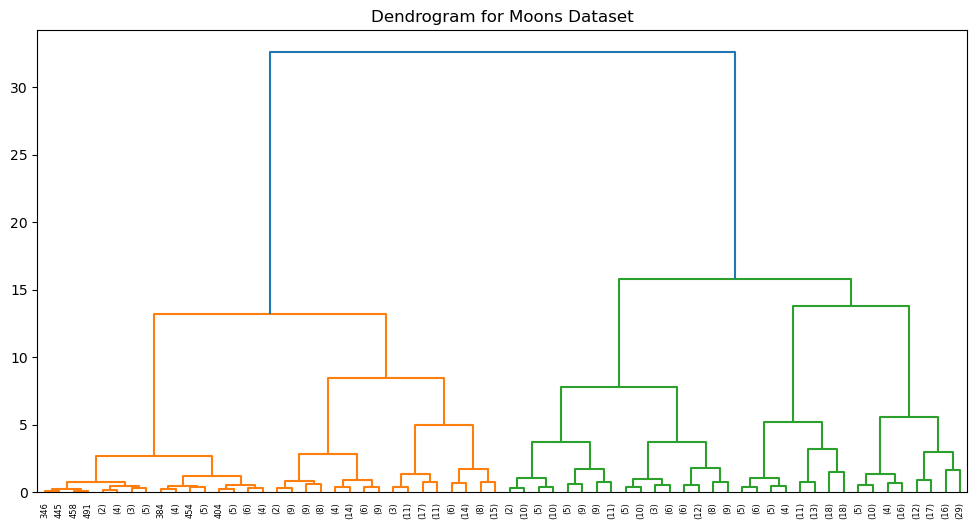

In [39]:
# Standardize features
X_moons_scaled = StandardScaler().fit_transform(X_moons)

# Apply hierarchical clustering
Z_moons = linkage(X_moons_scaled, method="ward")

# Plot dendrogram
plt.figure(figsize=(12,6))
dendrogram(Z_moons, truncate_mode="level", p=5)
plt.title("Dendrogram for Moons Dataset")
plt.show()

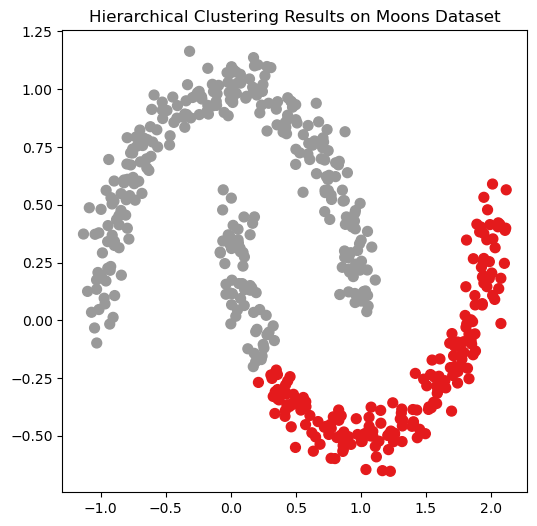

In [43]:
# Form 2 clusters
clusters_moons = fcluster(Z_moons, t=2, criterion="maxclust")

# Plot results
plt.figure(figsize=(6,6))
plt.scatter(X_moons[:,0], X_moons[:,1], c=clusters_moons, cmap="Set1", s=50)
plt.title("Hierarchical Clustering Results on Moons Dataset")
plt.show()

In [46]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

# Evaluate results
ari_moons = adjusted_rand_score(y_moons, clusters_moons)
sil_score_moons = silhouette_score(X_moons_scaled, clusters_moons)

print("ARI (Adjusted Rand Index):", ari_moons)
print("Silhouette Score:", sil_score_moons)

ARI (Adjusted Rand Index): 0.5829066956399189
Silhouette Score: 0.4575551165005858
